In [1]:
import tensorflow as tf
import keras
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import root_mean_squared_error

In [ ]:
tf.config.run_functions_eagerly(True)

## 触るな

#### その前に，データを切り分ける

In [ ]:
data = data.sort_values(['week_id', 'nikkei'])

In [ ]:
data = data.rename(columns={
    '１株当たり配当金': 'DPS',
    'その他流動資産／その他の金融資産':'その他流動資産',
    'その他流動負債／その他の金融負債':'その他流動負債',
    '法人税等調整額／繰延税金費用':'法人税等調整額',
    'その他無形固定資産／その他無形資産':'その他無形固定資産',
    'その他の小計欄より上の営業キャッシュフロー':'その他の小計欄より上の営業CF',
    '投資有価証券の取得による支出（▲）': '投資有価証券の取得による支出',
    'その他の流動資産の減少額（▲増）': 'その他の流動資産の減少額',
})

In [ ]:
data.reset_index(drop=True, inplace=True)
data

In [ ]:
data[data['nikkei'] == 'N0056747']

In [ ]:
data['nikkei'].nunique()

In [ ]:
data.columns

In [ ]:
tech_order =[
    '上場フラグ',
    'nikkei',
    'week_id',
    'return',
    '10mom',
    'rsi14',
    'signal',
    'macd',
    'hist',
    'slowk',
    'slowd',
    '5ma',
    '15ma',
    '40ma',
    'bb1u',
    'bb1l',
    'bb2u',
    'bb2l',
    'beta',
    'volatility',
]

In [ ]:
funda_order = [
    '上場フラグ',
    'nikkei',
    'week_id',

    # 財務指標
    '固定比率',
    '流動比率',
    '売上高総利益率',
    '売上高営業利益率',
    '売上高経常利益率',
    '株主資本回転率',
    '総資産回転率',
    'ギアリング比率',
    '自己資本比率',
    'フリーキャッシュフロー',
    '有利子負債',
    'ROE',
    'ROA',
    'PER',
    'PBR',
    'PCFR',
    'EPS',
    'BPS',
    'DPS',
    'CFPS',
    'EV',
    'EBITDA',
]

In [ ]:
fiscal_order = [
    '上場フラグ',
    'nikkei',
    'week_id',

    # BS
    'その他流動資産',
    'その他流動負債',
    'その他無形固定資産',

    # PL
    '法人税等調整額',
    'その他営業外費用',
    'その他営業外収益',
    '営業利益',
    '営業外費用',
    '営業費用',
    '非支配株主に帰属する当期純利益',
    'その他特別利益',

    # CF
    '有形固定資産の売却による収入',
    '無形固定資産の売却による収入',
    '固定資産の売却による収入',
    '投資有価証券の取得による支出',
    '投資その他の資産の売却による収入',
    'その他の流動資産の減少額',
    'その他の小計欄より上の営業CF',
]

In [ ]:
all_data = [
    '上場フラグ',
    'nikkei',
    'week_id',

    # tech
    'return',
    '10mom',
    'rsi14',
    'signal',
    'macd',
    'hist',
    'slowk',
    'slowd',
    '5ma',
    '15ma',
    '40ma',
    'bb1u',
    'bb1l',
    'bb2u',
    'bb2l',
    'beta',
    'volatility',

    # fundamental
    '固定比率',
    '流動比率',
    '売上高総利益率',
    '売上高営業利益率',
    '売上高経常利益率',
    '株主資本回転率',
    '総資産回転率',
    'ギアリング比率',
    '自己資本比率',
    'フリーキャッシュフロー',
    '有利子負債',
    'ROE',
    'ROA',
    'PER',
    'PBR',
    'PCFR',
    'EPS',
    'BPS',
    'DPS',
    'CFPS',
    'EV',
    'EBITDA',

    # fiscal
    # - BS
    'その他流動資産',
    'その他流動負債',
    'その他無形固定資産',

    # - PL
    '法人税等調整額',
    'その他営業外費用',
    'その他営業外収益',
    '営業利益',
    '営業外費用',
    '営業費用',
    '非支配株主に帰属する当期純利益',
    'その他特別利益',

    # - CF
    '有形固定資産の売却による収入',
    '無形固定資産の売却による収入',
    '固定資産の売却による収入',
    '投資有価証券の取得による支出',
    '投資その他の資産の売却による収入',
    'その他の流動資産の減少額',
    'その他の小計欄より上の営業CF',
]

In [ ]:
tech_df     = data[tech_order   + ['next_return', 'next_close']]
funda_df    = data[funda_order  + ['next_return', 'next_close']]
fiscal_df   = data[fiscal_order + ['next_return', 'next_close']]
all_df      = data[all_data     + ['next_return', 'next_close']]

In [ ]:
# fiscal_corr = fiscal_df.corr().unstack().abs().reset_index()
# fiscal_corr.columns = ['feature_1', 'feature_2', 'correlation']
# fiscal_corr = fiscal_corr[fiscal_corr['correlation'].abs() < 1.0]
# fiscal_corr = fiscal_corr.sort_values(by='correlation', ascending=False)
# fiscal_corr = fiscal_corr.reset_index(drop=True)
# fiscal_corr = fiscal_corr[fiscal_corr.index % 2 == 0].reset_index(drop=True)
# fiscal_corr.head(40)

#### データを使用するフォーマットに成形

In [ ]:
all_wed_csv = pd.read_csv('weekly_All_wed_v2.csv')

In [ ]:
all_df_with_yearID = pd.merge(
    all_df,
    all_wed_csv[['week_id', 'separate_flag']],
    on='week_id',
    how='left'
)

In [ ]:
all_df_with_yearID.groupby('separate_flag').apply(lambda group: group.to_csv(f'each_year_data/all_df_{group.name}.csv', index=False))

In [ ]:
csv_list = [pd.read_csv(fp) for fp in Path('each_year_data').rglob('.') if fp.suffix == '.csv']

input_csv_set = [
    pd.concat([csv1, csv2, csv3, csv4], axis=0).reset_index(drop=True)
    for csv1, csv2, csv3, csv4, in zip(
        csv_list[1:-3],
        csv_list[2:-2],
        csv_list[3:-1],
        csv_list[4:],
    )
]

In [ ]:
input_csv_set = [csv.sort_values(['nikkei', 'week_id']).reset_index(drop=True) for csv in input_csv_set]

In [ ]:
len(input_csv_set)

In [ ]:
input_csv_set[0]

In [ ]:
for i, input_csv in enumerate(input_csv_set):
    print('\r', f'Processing set {i+1}-{i+4}', end='   ')
    # input_csv = input_csv.drop(columns=['nikkei', 'week_id'], errors='ignore')
    input_csv = input_csv.fillna(0, inplace=False)
    input_csv.to_csv(f'every_3year_data/input_csv_set_{i+2}-{i+5}.csv', index=False)

## 1. ここだけ使用すること

#### 元データの取り込み

In [ ]:
data = pd.read_csv('weekly_All_v1.csv')

#### 使用するデータだけ抜き出す

In [ ]:
data = data[data['week_id'] >= 40]

In [ ]:
# 正解ラベルを準備する
data['next_close'] = data.groupby('nikkei')['close'].shift(-1)
data['next_return'] = data.groupby('nikkei')['return'].shift(-1)

In [ ]:
# 正解ラベルが存在しないため，最後尾の週は削除する
data = data.groupby('nikkei').apply(lambda x: x[:-1]).reset_index(drop=True)

In [ ]:
data.to_csv('weekly_All_v2.csv', index=False)

#### 読み込みだけする場合

In [5]:
All_df = pd.read_csv('weekly_All_v2.csv')
financial_data = All_df.copy()

## 1. モデルを記述（必ず実行）

#### モデルの具体的な設定

＠ notebook\tmp\create_simple_LSTM.ipynb

ここに元のモデルが記述されている

In [ ]:
lstm_cfg = {
    'neurons_in_layer' : 64,
    'learning_rate' : 0.001,
    'decay' : 0,
    'hidden_layers' : 1,
    'optimizer' : 'Adam',
    'early_stopping' : 5,
    'loss_function' : 'mean_squared_error',
    'epochs' : 100,
    'dropout_rate' : 0.5,
    'batch_size' : 32,
}

In [9]:
# どちらかをコメントアウト
X_drop_cols = ['nikkei', 'week_id', 'next_return', '上場フラグ', '期中平均株式数累計', '当期純利益', 'open', 'weekly_high', 'weekly_low', 'close']  # 予測対象： next_close
# X_drop_cols = ['nikkei', 'week_id', 'next_close', '上場フラグ', '期中平均株式数累計', '当期純利益', 'open', 'weekly_high', 'weekly_low', 'close'] # 予測対象： next_return

In [14]:
def build_and_train_LSTM(X_train: np.ndarray, y_train: np.ndarray):

    print('Building and training LSTM model...')
    print(tf.executing_eagerly())
    model = Sequential()
    # 1層目
    model.add(LSTM(units=lstm_cfg['neurons_in_layer'], return_sequences=True, 
                   input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(lstm_cfg['dropout_rate']))
    
    # 2層目
    model.add(LSTM(units=lstm_cfg['neurons_in_layer'], return_sequences=False))

    # 出力層
    model.add(Dense(units=1))

    model.compile(optimizer=lstm_cfg['optimizer'], loss=lstm_cfg['loss_function'])
    model.fit(X_train, y_train,
              epochs=lstm_cfg['epochs'],
              batch_size=lstm_cfg['batch_size'],
              validation_split=0.2,
              callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=lstm_cfg['early_stopping'])])
    
    return model

In [13]:
def parse_data_for_LSTM(data: pd.DataFrame, target_col: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    window = 15

    train_range = int(len(data)*0.8)

    X = []
    y = []

    if len(data) < window + 1:
        return None, None, None, None

    for i in range(len(data) - window):
        start = i
        end = i + window
        
        # 特徴量は全部の列
        X.append(data.iloc[start:end, :].values)
        
        # y は列名で指定
        y.append(data.iloc[end, data.columns.get_loc(target_col)])

    X, y = np.array(X), np.array(y)

    X_train, y_train = X[:train_range], y[:train_range]
    X_test, y_test = X[train_range:], y[train_range:]

    if target_col == 'next_close':
        mask_train = y_train != 0
        mask_test = y_test != 0

        idx_train = np.where(mask_train, np.arange(len(mask_train)), 0)
        idx_test = np.where(mask_test, np.arange(len(mask_test)), 0)

        # np.maximum.accumulate で最後に非ゼロのインデックスを保持
        idx_train = np.maximum.accumulate(idx_train)
        idx_test = np.maximum.accumulate(idx_test)

        filled_train = mask_train[idx_train]
        filled_test = mask_test[idx_test]

        X_train = X_train[filled_train]
        y_train = y_train[filled_train]
        
        X_test = X_test[filled_test]
        y_test = y_test[filled_test]
    
    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    # X_train = X_train.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    # X_test = X_test.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    return X_train, y_train, X_test, y_test

In [15]:
def activate_lstm(group: pd.DataFrame, y_label: str = 'next_close', last_nikkei: int = 0):

    data = group.copy()
    group_name = data['nikkei'].iloc[0]

    if int(group_name[1:]) <= last_nikkei:
        print('\r', f'Skipping group {group_name} as it is before or equal to last_nikkei {last_nikkei}.', end='   ')
        return None
    print(f'\nStarting LSTM for group: {group["nikkei"].iloc[0]}')

    # 上場銘柄だけ・欠損を0で埋める・週ID順に並べる
    data = data[data['上場フラグ'] == 1].reset_index(drop=True).ffill()
    data = data.sort_values('week_id').reset_index(drop=True)
    data = data.drop(columns=X_drop_cols, errors='ignore')

    # データ分割
    X_train, y_train, X_test, y_test = parse_data_for_LSTM(data, y_label)

    if X_train is None or y_train is None or X_test is None or y_test is None:
        print(f'Skipping group {group_name} due to insufficient data length.')
        return None

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        print(f'Skipping group {group_name} due to insufficient data after scaling.')
        return None

    print("Original shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    # スケーリング
    X_scaler = MinMaxScaler(feature_range=(0, 1))
    y_scaler = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled = X_scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
    X_test_scaled = X_scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

    print(f'X_train_scaled shape: {X_train_scaled.shape}')
    print(f'X_test_scaled shape : {X_test_scaled.shape}')

    # モデル作成・学習
    model = build_and_train_LSTM(X_train_scaled, y_train_scaled)

    # 予測
    train_predictions = model.predict(X_train_scaled)
    test_predictions = model.predict(X_test_scaled)

    # 逆スケーリング
    train_predictions_real = y_scaler.inverse_transform(train_predictions.reshape(-1, 1)).reshape(train_predictions.shape)
    test_predictions_real  = y_scaler.inverse_transform(test_predictions.reshape(-1, 1)).reshape(test_predictions.shape)
    
    train_real = y_scaler.inverse_transform(y_train_scaled.reshape(-1, 1)).reshape(y_train_scaled.shape)
    test_real  = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(y_test_scaled.shape)

    # プロット
    plt.figure(figsize=(12,6))
    
    # 訓練データ
    plt.plot(train_real, label='True', color='black')
    plt.plot(train_predictions_real, label='Train Pred', color='blue')

    # テストデータ（訓練の後にプロットする）
    plt.plot(range(len(y_train), len(y_train)+len(y_test)), test_real, color='black')
    plt.plot(range(len(y_train), len(y_train)+len(y_test)), test_predictions_real, label='Test Pred', color='red')
    plt.title(f'LSTM Predictions vs True Values for {group_name}')
    plt.legend()
    plt.xlabel('T[week]')
    plt.ylabel('close price')
    plt.savefig(f'../../images/dev_LSTM/LSTM_PREDvsREAL_{group_name}.png')
    # plt.show()
    print(f'Finished plotting for {group_name}')

    # モデル保存
    with open(f'../../model/dev_LSTM/LSTM_model_{group_name}.pkl', 'wb') as f:
        pickle.dump(model, f)

    print(f'Saved model for {group_name}')

    # 誤差計算（逆スケール済み）
    # [error = test_predictions_real - test_real]

    return (test_predictions_real, test_real)

## 2. アクティベート

#### モデルの実行

In [ ]:
grouped_by_nikkei_error = (
    financial_data.copy()
    .groupby('nikkei')
    .apply(
        lambda group : activate_lstm(group, y_label='next_close', last_nikkei=32035)
    )
)

In [ ]:
error = pd.DataFrame(grouped_by_nikkei_error).reset_index()
error.columns = ['nikkei', 'prediction_error']
error.reset_index(inplace=True)

## 3. 評価を行う

In [124]:
loaded_model = pickle.load(open('../../model/dev_LSTM/LSTM_model_N0000001.pkl', 'rb'))

In [125]:
kyokuyo = financial_data[financial_data['nikkei'] == 'N0000001'].reset_index(drop=True)

In [126]:
kyokuyo_dropped = kyokuyo.drop(columns=X_drop_cols, errors='ignore')
kyokuyo_dropped = kyokuyo_dropped[kyokuyo_dropped.notna().all(axis=1)]

In [127]:
kyokuyo_dropped

,return,10mom,slowk,slowd,5ma,15ma,40ma,rsi14,signal,macd,...,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility,next_close
0,0.014493,-0.020979,62.962963,50.058642,1106.238209,1158.527164,1203.667239,47.313646,-12.091228,-24.905558,...,239.531674,4.007685,2.133396e+11,4.775239,285.406886,17.568271,65.107197,0.596543,0.038671,1160.161194
1,0.014286,-0.034014,73.076923,63.479345,1129.114627,1152.535721,1205.914030,49.051287,-14.065818,-21.964181,...,242.953555,4.064938,2.151840e+11,4.775239,285.406886,17.568271,66.037300,0.533854,0.034969,1151.991045
2,-0.007042,-0.040816,70.673077,68.904321,1135.650746,1148.178308,1207.752313,48.195389,-15.264880,-20.061128,...,241.242615,4.036311,2.142618e+11,4.775239,285.406886,17.568271,65.572249,0.494944,0.034465,1151.991045
3,0.000000,-0.007042,56.089744,66.613248,1147.088955,1143.276219,1209.386343,48.195389,-15.880207,-18.341515,...,103.116391,3.935526,2.066648e+11,11.171755,292.715925,19.561645,58.890294,0.507384,0.034371,1135.650746
4,-0.014184,-0.021127,33.012821,53.258547,1148.722985,1141.642189,1208.977836,46.320629,-16.321910,-18.088720,...,101.653747,3.879703,2.048204e+11,11.171755,292.715925,19.561645,58.054971,0.447235,0.031705,1094.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1152,-0.044271,-0.032938,25.699169,22.184844,3770.000000,3830.333333,3679.000000,45.596645,56.957409,36.327049,...,66.134603,1.257352,1.420631e+11,55.492886,2918.832560,142.509463,25.752676,0.674339,0.027005,3720.000000
1153,0.013624,-0.049808,33.582766,28.624271,3741.000000,3829.666667,3680.875000,48.269159,51.105739,27.699061,...,67.035619,1.274482,1.425992e+11,55.492886,2918.832560,142.509463,26.103530,0.657476,0.026837,3780.000000
1154,0.016129,-0.060870,31.360544,30.214160,3748.000000,3830.333333,3684.250000,51.357172,45.966572,25.409906,...,68.116839,1.295038,1.432425e+11,55.492886,2918.832560,142.509463,26.524554,0.675992,0.027024,3795.000000
1155,0.003968,-0.050063,52.500000,39.147770,3761.000000,3831.000000,3688.375000,52.126566,41.677942,24.523419,...,68.387144,1.300177,1.434034e+11,55.492886,2918.832560,142.509463,26.629811,0.679812,0.027024,3810.000000


In [128]:
X_train, y_train, X_test, y_test = parse_data_for_LSTM(kyokuyo_dropped, target_col='next_close')

(925, 15, 58) (925,) (217, 15, 58) (217,)


In [129]:
X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))
X_scaler.fit(X_train.reshape(-1, X_train.shape[2]))
X_test_scaled = X_scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
y_scaler.fit(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
predictions = loaded_model.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
plt.plot(predictions)

In [ ]:
# calc rmse
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test_scaled[:-1], predictions[:-1])
rmse


In [ ]:
modelS_path = Path('../../model/dev_LSTM/')
all_model_pkl = list(modelS_path.rglob('LSTM_model_*.pkl'))

In [ ]:
square_list = []
empty_list = []

for model_path in all_model_pkl:
    # モデルを読み込み
    with open(model_path, 'rb') as f:
        activated_model = pickle.load(f)
    
    nikkei = model_path.stem[11:]
    print(f'Activated model for nikkei: {nikkei}')
    
    # 対応する株価データ
    stock_data = financial_data[financial_data['nikkei'] == nikkei].reset_index(drop=True)
    stock_data_dropped = stock_data.drop(columns=X_drop_cols, errors='ignore')
    stock_data_dropped = stock_data_dropped[stock_data_dropped.notna().all(axis=1)]

    if stock_data_dropped.empty:
        print(f'Skipping nikkei {nikkei} due to insufficient data after dropping NaNs.')
        empty_list.append(nikkei)
        continue
    
    # LSTM用にデータを分割
    X_train, y_train, X_test, y_test = parse_data_for_LSTM(stock_data_dropped, target_col='next_close')

    if X_train is None or y_train is None or X_test is None or y_test is None:
        print(f'Skipping nikkei {nikkei} due to insufficient data length.')
        empty_list.append(nikkei)
        continue

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        print(f'Skipping nikkei {nikkei} due to insufficient data after scaling.')
        empty_list.append(nikkei)
        continue

    if y_test.shape[0] < 2:
        print(f'Skipping nikkei {nikkei} due to insufficient y_test data for RMSE calculation.')
        empty_list.append(nikkei)
        continue
    
    # スケーリング
    X_scaler = MinMaxScaler(feature_range=(0, 1))
    y_scaler = MinMaxScaler(feature_range=(0, 1))
    
    X_train_scaled = X_scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
    X_test_scaled = X_scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
    
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
    
    # NaNを0に置換
    y_test_scaled = np.nan_to_num(y_test_scaled)
    
    # 予測
    predictions = activated_model.predict(X_test_scaled)
    predictions = np.nan_to_num(predictions)

    y_test_original = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(y_test_scaled.shape)
    predictions_original = y_scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(predictions.shape)
    
    # RMSE計算
    rmse = root_mean_squared_error(y_test_original[:-1], predictions_original[:-1])
    print(f'RMSE for nikkei {nikkei}: {rmse}')
    
    square_list.append(rmse)

# 全モデルの平均RMSE
average_rmse = np.mean(square_list)
print(f'Average RMSE across all models: {average_rmse}')


In [ ]:
all_rmse = sum(square_list) / len(square_list)

In [ ]:
all_rmse

In [ ]:
rmse_df = pd.DataFrame({
    'rmse': square_list
})

In [ ]:
rmse_df.sort_values(by='rmse').tail(10)

In [ ]:
rmse_df.describe()

In [ ]:
empty_list

## 4. ラグ検知

In [130]:
model = pickle.load(open('../../model/dev_LSTM/LSTM_model_N0000001.pkl', 'rb'))

In [131]:
y_test_original = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(y_test_scaled.shape)
predictions_original = y_scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(predictions.shape)

In [132]:
Observations = y_test_original
Predictions = predictions_original

In [133]:
range_num = 100

In [134]:
Observations_df = pd.DataFrame(Observations, columns=["Actual"]).reset_index(drop=True)
Predictions_df = pd.DataFrame(Predictions, columns=["Predicted"]).reset_index(drop=True)
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1).shift(-i) for i in range(-range_num, range_num)], axis=1
)


In [135]:
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1), shift_series, Observations_df.diff().shift(-1)], axis=1
)

In [136]:
shift_series.columns = ['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual']

In [137]:
import scipy.stats as stats
import seaborn as sns
standardized_data = (stats.zscore(shift_series.dropna()))
lagged_df = pd.DataFrame(standardized_data, columns=['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual'])
corr = lagged_df.corr()['Actual']

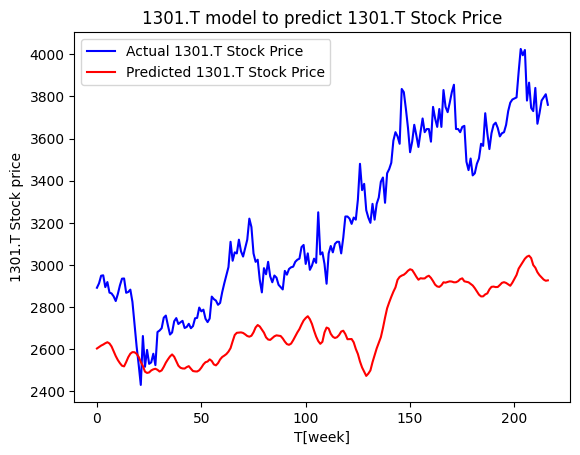

In [139]:
plt.plot(Observations, label='Actual 1301.T Stock Price', color='blue')
plt.plot(Predictions, label='Predicted 1301.T Stock Price', color='red')
plt.xlabel('T[week]')
plt.ylabel('1301.T Stock price')
plt.title('1301.T model to predict 1301.T Stock Price')
plt.legend()

Text(0, 0.5, 'cross-correlation')

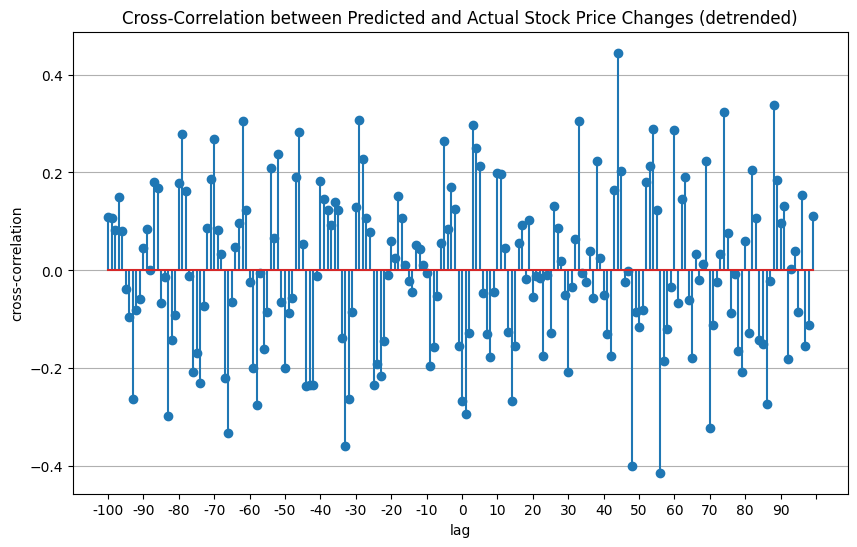

In [122]:
plt.figure(figsize=(10, 6))
plt.stem([f'{i}' for i in range(-range_num, range_num)], corr[1:-1])
plt.xlabel("lag")
plt.title("Cross-Correlation between Predicted and Actual Stock Price Changes (detrended)")
plt.grid(axis='y')
plt.xticks(range(0, len(corr), 10))
plt.ylabel("cross-correlation")

In [123]:
mape = np.mean(np.abs((Observations - Predictions) / Observations)) * 100
print(f"MAPE: {mape}%")

MAPE: 15.457712064566797%
